# Heuristicas e Regras de Negocio
Validacao do motor decisorio baseado em regras. O projeto atual usa heuristicas, nao um modelo preditivo treinado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

contratos = pd.read_csv('contratos_clean.csv')
pagamentos = pd.read_csv('pagamentos_clean.csv', parse_dates=['Data_Vencimento', 'Data_Pagamento'])

## Regra de risco
- Alto: atraso inicial > 60 dias, status Ajuizado ou score > 70.
- Medio: atraso inicial entre 16 e 60 dias ou status Insucesso.
- Baixo: atraso inicial ate 15 dias sem agravantes.

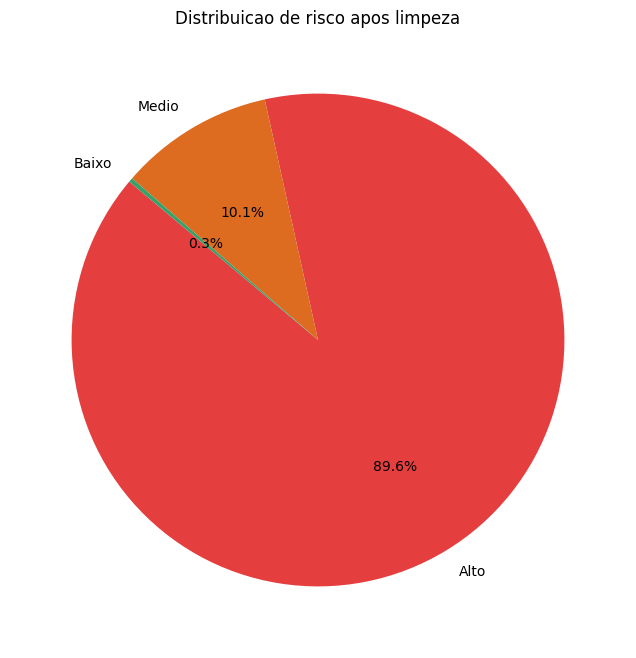

Nivel_Risco
Alto     8958
Medio    1014
Baixo      28
Name: count, dtype: int64
Nivel_Risco
Alto     89.58
Medio    10.14
Baixo     0.28
Name: count, dtype: float64


In [2]:
def classificar_risco(row):
    dias = row['Dias_Em_Atraso_Inicial']
    status = row['Status_Cobranca']
    score = row['Score_Interno_Risco']

    if dias > 60 or status == 'Ajuizado' or score > 70:
        return 'Alto'
    if dias > 15 or status == 'Insucesso':
        return 'Medio'
    return 'Baixo'


contratos['Nivel_Risco'] = contratos.apply(classificar_risco, axis=1)
dist_risco = contratos['Nivel_Risco'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    dist_risco,
    labels=dist_risco.index,
    autopct='%1.1f%%',
    colors=['#e53e3e', '#dd6b20', '#38a169'],
    startangle=140,
)
plt.title('Distribuicao de risco apos limpeza')
plt.show()

print(dist_risco)
print((dist_risco / len(contratos) * 100).round(2))

## Contratos prioritarios

In [3]:
prioritarios = contratos[
    (contratos['Nivel_Risco'] == 'Alto')
    & (contratos['Status_Cobranca'].isin(['Em Aberto', 'Insucesso', 'Ajuizado']))
].sort_values(['Valor_Inadimplente_Inicial', 'Dias_Em_Atraso_Inicial'], ascending=False)

print(f'Contratos de risco alto: {int((contratos["Nivel_Risco"] == "Alto").sum())}')
print(f'Contratos prioritarios para cobranca: {len(prioritarios)}')
print(prioritarios[
    ['ID_Contrato', 'Nome_Assessoria', 'Regiao_Cliente', 'Status_Cobranca',
     'Dias_Em_Atraso_Inicial', 'Score_Interno_Risco', 'Valor_Inadimplente_Inicial']
].head(15).to_string(index=False))

Contratos de risco alto: 8958
Contratos prioritarios para cobranca: 5940
     ID_Contrato              Nome_Assessoria Regiao_Cliente Status_Cobranca  Dias_Em_Atraso_Inicial  Score_Interno_Risco  Valor_Inadimplente_Inicial
CONTR_2026_09355 Fenix Recuperacao de Credito       Nordeste       Insucesso                     134                 54.0                    45624.51
CONTR_2026_05614 Fenix Recuperacao de Credito            Sul       Em Aberto                      70                 46.0                    44015.49
CONTR_2026_01546     Vertice Asset e Cobranca            Sul       Insucesso                     113                 51.0                    43714.30
CONTR_2026_09229     Vertice Asset e Cobranca   Centro-Oeste       Em Aberto                      79                 24.0                    42760.26
CONTR_2026_01929    Nexus Mediacao Financeira            Sul       Em Aberto                     109                 57.0                    36532.26
CONTR_2026_06542     Acerta